<a href="https://colab.research.google.com/github/yogesh-bhattarai/Django/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("python titanic dataset") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

os.listdir("/content/drive/MyDrive/dataset")

['property.csv',
 'Airline_Delay_Cause.csv',
 'Diabetes.csv',
 'titanic_synthetic_data.csv']

In [6]:
df = spark.read.csv(
    "/content/drive/MyDrive/dataset/titanic_synthetic_data.csv",
    header=True,
    inferSchema=True
)

df.show()

+------+---+-----+-----+------------------+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|              Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+------------------+---+--------+----------+----------+
|     3| 42|    6|    7|397.00178367782024|  0|       0|         0|         1|
|     1| 52|    6|    7|302.12770032784186|  0|       0|         1|         0|
|     3| 25|    3|    8| 427.1058765283985|  1|       1|         1|         0|
|     3| 32|    9|    7| 326.8049924602327|  1|       0|         0|         0|
|     1| 40|    0|    5|17.718838497771657|  0|       0|         0|         0|
|     1| 20|    7|    2|402.54904361394784|  0|       0|         0|         0|
|     3| 76|    4|    9| 52.61038014285054|  0|       0|         1|         0|
|     2| 22|    4|    7|196.48213366632623|  1|       0|         0|         0|
|     3| 78|    4|    8| 388.6259182464271|  1|       0|         0|         0|
|     3| 15|    1|    8|299.45900279822325|  1|     

In [7]:
df.show(5)

+------+---+-----+-----+------------------+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|              Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+------------------+---+--------+----------+----------+
|     3| 42|    6|    7|397.00178367782024|  0|       0|         0|         1|
|     1| 52|    6|    7|302.12770032784186|  0|       0|         1|         0|
|     3| 25|    3|    8| 427.1058765283985|  1|       1|         1|         0|
|     3| 32|    9|    7| 326.8049924602327|  1|       0|         0|         0|
|     1| 40|    0|    5|17.718838497771657|  0|       0|         0|         0|
+------+---+-----+-----+------------------+---+--------+----------+----------+
only showing top 5 rows


In [8]:
df.printSchema()

root
 |-- Pclass: integer (nullable = true)
 |-- Age: integer (nullable = true)
 |-- SibSp: integer (nullable = true)
 |-- Parch: integer (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Sex: integer (nullable = true)
 |-- Survived: integer (nullable = true)
 |-- Embarked_Q: integer (nullable = true)
 |-- Embarked_S: integer (nullable = true)



In [9]:
print("Rows:", df.count())
print("Columns:", len(df.columns))

Rows: 1000000
Columns: 9


In [10]:
df.describe().show()

+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+
|summary|            Pclass|               Age|             SibSp|             Parch|              Fare|               Sex|          Survived|         Embarked_Q|        Embarked_S|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+
|  count|           1000000|           1000000|           1000000|           1000000|           1000000|           1000000|           1000000|            1000000|           1000000|
|   mean|          1.999411|         39.517847|          4.500906|          4.497493| 254.9829083944402|           0.50082|           0.49987|           0.332717|          0.333661|
| stddev|0.8168263709530482|23.092708389398037|2.8714427426552285|2.8728101169393594|141.5

In [13]:
df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+------+---+-----+-----+----+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+----+---+--------+----------+----------+
|     0|  0|    0|    0|   0|  0|       0|         0|         0|
+------+---+-----+-----+----+---+--------+----------+----------+



In [14]:
df.groupBy("Survived").count().show()

+--------+------+
|Survived| count|
+--------+------+
|       1|499870|
|       0|500130|
+--------+------+



In [15]:
df.groupBy("Sex").count().show()

+---+------+
|Sex| count|
+---+------+
|  1|500820|
|  0|499180|
+---+------+



In [16]:
df.groupBy("Pclass").count().show()

+------+------+
|Pclass| count|
+------+------+
|     1|333897|
|     3|333308|
|     2|332795|
+------+------+



In [17]:
df.groupBy("Sex", "Survived").count().show()

+---+--------+------+
|Sex|Survived| count|
+---+--------+------+
|  1|       0|250736|
|  1|       1|250084|
|  0|       0|249394|
|  0|       1|249786|
+---+--------+------+



In [18]:
df.select(avg("Fare")).show()

+-----------------+
|        avg(Fare)|
+-----------------+
|254.9829083944402|
+-----------------+



In [19]:
numeric_columns = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Sex",
    "Embarked_Q",
    "Embarked_S",
    "Survived"
]

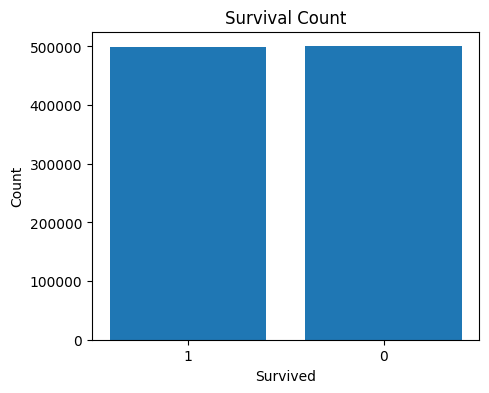

In [23]:
survival = df.groupBy("Survived").count().toPandas()

plt.figure(figsize=(5,4))
plt.bar(survival["Survived"].astype(str), survival["count"])
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

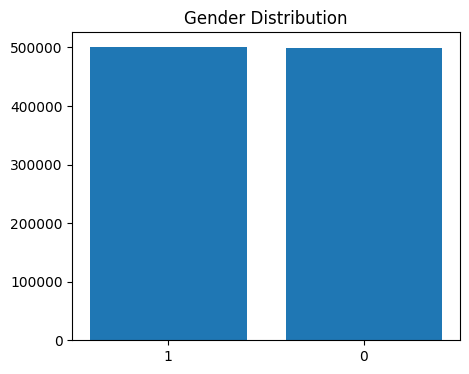

In [24]:
gender = df.groupBy("Sex").count().toPandas()

plt.figure(figsize=(5,4))
plt.bar(gender["Sex"].astype(str), gender["count"])
plt.title("Gender Distribution")
plt.show()

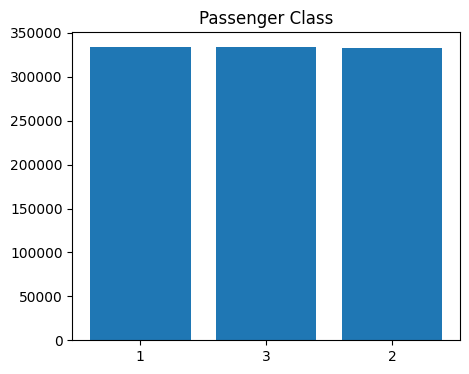

In [25]:
pclass = df.groupBy("Pclass").count().toPandas()

plt.figure(figsize=(5,4))
plt.bar(pclass["Pclass"].astype(str), pclass["count"])
plt.title("Passenger Class")
plt.show()

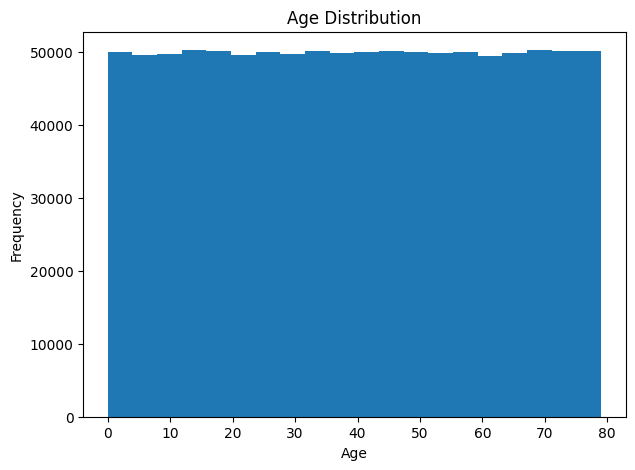

In [26]:
age = df.select("Age").toPandas()

plt.figure(figsize=(7,5))
plt.hist(age["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

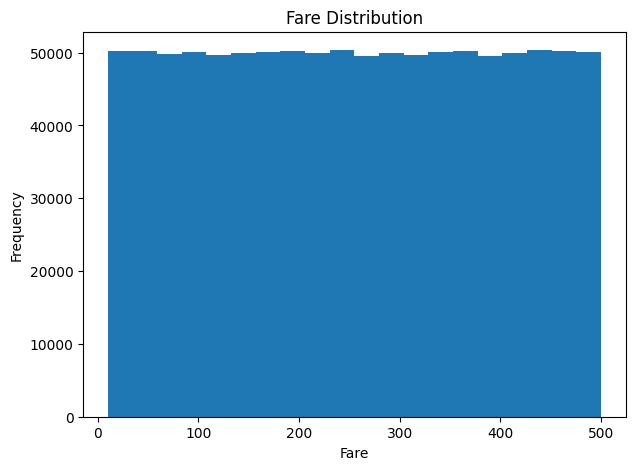

In [27]:
fare = df.select("Fare").toPandas()

plt.figure(figsize=(7,5))
plt.hist(fare["Fare"], bins=20)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

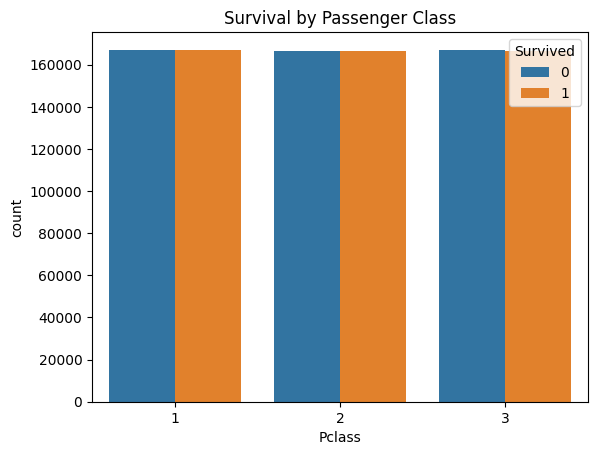

In [30]:
survival_class = df.groupBy("Pclass", "Survived").count().toPandas()

sns.barplot(
    data=survival_class,
    x="Pclass",
    y="count",
    hue="Survived"
)

plt.title("Survival by Passenger Class")
plt.show()

In [31]:
feature_columns = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Sex",
    "Embarked_Q",
    "Embarked_S"
]

In [32]:
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

data = assembler.transform(df)

In [33]:
train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)

In [34]:
print(train_data.count())
print(test_data.count())

799987
200013


In [37]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol="Survived"
)

model = lr.fit(train_data)

In [38]:
predictions = model.transform(test_data)

In [39]:
predictions.select(
    "Survived",
    "prediction",
    "probability"
).show(10, truncate=False)

+--------+----------+----------------------------------------+
|Survived|prediction|probability                             |
+--------+----------+----------------------------------------+
|1       |1.0       |[0.49994098746763116,0.5000590125323688]|
|0       |0.0       |[0.5015111645074949,0.4984888354925051] |
|1       |0.0       |[0.5000367234443062,0.49996327655569384]|
|1       |0.0       |[0.5002834977206528,0.49971650227934716]|
|1       |0.0       |[0.5017524481278081,0.49824755187219194]|
|0       |0.0       |[0.5004806053272883,0.49951939467271167]|
|1       |0.0       |[0.5013674835277859,0.49863251647221407]|
|1       |0.0       |[0.5015988226011708,0.49840117739882916]|
|0       |1.0       |[0.49986344643507996,0.50013655356492]  |
|1       |0.0       |[0.5004563200904704,0.49954367990952964]|
+--------+----------+----------------------------------------+
only showing top 10 rows


In [40]:
accuracy = MulticlassClassificationEvaluator(
    labelCol="Survived",
    predictionCol="prediction",
    metricName="accuracy"
)

print("Accuracy:", accuracy.evaluate(predictions))

Accuracy: 0.50244734092284


In [41]:
precision = MulticlassClassificationEvaluator(
    labelCol="Survived",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

print("Precision:", precision.evaluate(predictions))

Precision: 0.5030203043411821


In [42]:
recall = MulticlassClassificationEvaluator(
    labelCol="Survived",
    predictionCol="prediction",
    metricName="weightedRecall"
)

print("Recall:", recall.evaluate(predictions))

Recall: 0.50244734092284


In [43]:
f1 = MulticlassClassificationEvaluator(
    labelCol="Survived",
    predictionCol="prediction",
    metricName="f1"
)

print("F1 Score:", f1.evaluate(predictions))

F1 Score: 0.4882545322590828


In [44]:
auc = BinaryClassificationEvaluator(
    labelCol="Survived",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

print("AUC:", auc.evaluate(predictions))

AUC: 0.501889844796086


In [45]:
predictions.groupBy(
    "Survived",
    "prediction"
).count().show()

+--------+----------+-----+
|Survived|prediction|count|
+--------+----------+-----+
|       1|       0.0|66486|
|       0|       0.0|66834|
|       1|       1.0|33662|
|       0|       1.0|33031|
+--------+----------+-----+

